https://www.kaggle.com/datasets/yasserh/titanic-dataset

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset and take the first 50 passengers
data = pd.read_csv("titanic.csv").dropna().head(50)

# 2. Create the Feature Matrix (X)
features =["Pclass", "Age", "Fare"]
X_raw = data[features].values

# 3. Create the Binary Target Vector (y)
y = data["Survived"].values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

print("Raw Fare (First 3):", X_raw[:3, 2])
print("Normalized Fare (First 3):", X[:3, 2])

FileNotFoundError: [Errno 2] No such file or directory: 'titanic.csv'

# Activation Function Sigmoid

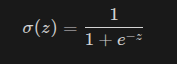

Converts the linear signals from (−∞ to +∞) into a probability (0 to 1)

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
m, n = X.shape  # m=50 passengers, n=3 features
w = np.zeros(n) # [0, 0, 0]
b = 0

In [ ]:
learning_rate = 0.1
iterations = 1000

loss_history = []

for i in range(iterations):
    # 1. Forward Pass (Linear Engine + Sigmoid)
    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    # 2. Calculate Error
    error = y_pred - y

    # 3. Backward Pass (Calculate Gradient/Feedback)
    dw = (1/m) * np.dot(X.T, error)
    db = (1/m) * np.sum(error)

    # 4. Update Weights (Gradient Descent)
    w = w - learning_rate * dw
    b = b - learning_rate * db


print("Final Learned Weights (w):", w)
print("Final Learned Bias (b):", b)

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate the final 'z' (Signal Strength) for all passengers
final_z = np.dot(X, w) + b

# 2. Calculate the probability based on our manual training
final_prob = sigmoid(final_z)

# 3. Create the Plot
plt.figure(figsize=(10, 6))

# Plot the Actual Passengers (0 or 1)
# We plot them against their 'z' score to separate them
plt.scatter(final_z, y, color='black', label='Actual Passengers (0 or 1)', zorder=5)

# Plot the Sigmoid Curve
# We must sort the values so the line connects smoothly
sorted_indices = np.argsort(final_z)
plt.plot(final_z[sorted_indices], final_prob[sorted_indices], color='blue', linewidth=3, label='Manual Sigmoid Curve')

# Draw Threshold
plt.axhline(0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')

# Formatting
plt.title("Manual Logistic Regression: Signal Strength (z) vs Survival")
plt.xlabel("Weighted Signal z = (w1*Class + w2*Age + w3*Fare + b)")
plt.ylabel("Probability of Survival")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
new_passengers_raw = np.array([
    [3, 22, 7.25],
    [1, 38, 71.28],
    [3, 60, 8.00],
    [1, 25, 300.00],
    [2, 28, 15.00]
])

# We must scale these raw numbers using the Training Mean/Std
# X_mean and X_std were calculated in the previous block
new_passengers_norm = (new_passengers_raw - X_mean) / X_std


# z = w1*x1 + w2*x2 + w3*x3 + b
z_manual = np.dot(new_passengers_norm, w) + b

prob_manual = sigmoid(z_manual)

print("\n--- MANUAL PREDICTION REPORT ---")
for i in range(5):
    # Determine Logic High (Survived) or Low (Died)
    prediction = "SURVIVED" if prob_manual[i] >= 0.5 else "DIED"

    print(f"Passenger {i+1}:")
    print(f"   Raw Input: Class {new_passengers_raw[i,0]}, Age {new_passengers_raw[i,1]}, Fare £{new_passengers_raw[i,2]}")
    print(f"   Normalized Input: {new_passengers_norm[i]}")
    print(f"   Calculated Signal (z): {z_manual[i]:.2f}")
    print(f"   Probability: {prob_manual[i]*100:.1f}%")
    print(f"   Final Decision: {prediction}")
    print("-" * 50)

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset and take the first 50 passengers
data = pd.read_csv("titanic.csv").dropna().head(50)

# 2. Create the Feature Matrix (X)
features =["Pclass", "Age", "Fare"]
X_raw = data[features].values

# 3. Create the Binary Target Vector (y)
y = data["Survived"].values

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

print("Raw Fare (First 3):", X_raw[:3, 2])
print("Normalized Fare (First 3):", X[:3, 2])

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create a blank model
model = LogisticRegression()

# Train the model (Run Gradient Descent to minimize error)
model.fit(X, y)

# 3. Extract the mathematical weights it learned
W = model.coef_
b = model.intercept_

print("Learned Weights (w1, w2, w3):", W)
print("Learned Bias (b):", b)

# Transfers the output through signoid function

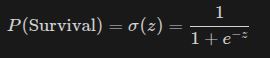

In [ ]:
# Let's say: 3rd Class, 40 years old, £8.00 ticket
new_passenger = np.array([[3, 40, 8.00]])

# Pass the data through the Sigmoid function
analog_probability = model.predict_proba(new_passenger)

# It outputs two numbers:[Chance of 0, Chance of 1]
print("Analog Probability [Died, Survived]:", analog_probability)

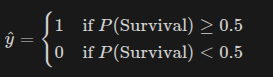

In [ ]:
# Apply the Threshold logic
digital_prediction = model.predict(new_passenger)

print("Final Digital Output:", digital_prediction)

In [ ]:
import matplotlib.pyplot as plt

# 1. Isolate just the 'Fare' column (Column index 2)
X_fare = X[:, 2].reshape(-1, 1)

# 2. Retrain a 1D model just for plotting
model_1D = LogisticRegression()
model_1D.fit(X_fare, y)

# 3. Generate a continuous X-axis (Fares from £0 to £150)
x_graph = np.linspace(0, 150, 100).reshape(-1, 1)

# 4. Calculate the Sigmoid Y-values for that continuous axis
y_sigmoid = model_1D.predict_proba(x_graph)[:, 1]

# 5. Plot the actual data points and the mathematical curve
plt.scatter(X_fare, y, color='black', label='Actual 50 Passengers')
plt.plot(x_graph, y_sigmoid, color='blue', linewidth=3, label='σ(z) Transfer Function')

# Draw the 0.5 threshold line
plt.axhline(0.5, color='red', linestyle='--', label='Logic Threshold (0.5)')

plt.xlabel("Ticket Fare (£)")
plt.ylabel("Probability of Survival P(y=1)")
plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

In [ ]:
# Features (rooms, bathrooms, sqft)
X = np.array([
    # Rooms, Bathrooms, Sqft
    [2, 1, 800],
    [3, 2, 1200],
    [4, 3, 2000],
    [3, 2, 1500],
    [5, 4, 2500]
])

# 0 = Not Expensive, 1 = Expensive
y = np.array([0, 0, 1, 0, 1])

In [ ]:
print(X)

In [ ]:
print(y)

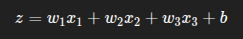

But the range of z is -infinite to +infinite and we are solving a classification problem

In [ ]:
model = LogisticRegression()

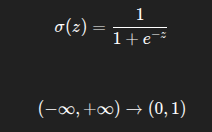

In [ ]:
model.fit(X, y)

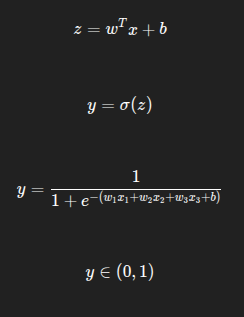

In [ ]:
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

In [ ]:
new_house = np.array([
    [3, 2, 1400],
    [4, 5, 2500]
])

probability = model.predict_proba(new_house)
prediction = model.predict(new_house)

print("Probability:", probability)
print("Prediction:", prediction)

In [ ]:
X_simple = X[:, 2].reshape(-1, 1)

model_simple = LogisticRegression()
model_simple.fit(X_simple, y)

x_range = np.linspace(500, 3000, 100).reshape(-1, 1)
y_prob = model_simple.predict_proba(x_range)[:,1]

plt.scatter(X_simple, y, label='Original Houses')
plt.plot(x_range, y_prob, color='blue')

# Extract Sqft for new houses and plot them with their predictions
new_house_sqft = new_house[:, 2].reshape(-1, 1)
plt.scatter(new_house_sqft, prediction, color='orange', marker='o', s=100, label='New Houses Prediction')

plt.xlabel("Sqft")
plt.ylabel("Probability of Expensive / Prediction")
plt.title("Logistic Regression with New House Predictions")
plt.legend()
plt.grid(True)
plt.show()